<a href="https://colab.research.google.com/github/AlanAlbertoJaimesV/connectatel-analysis/blob/main/An%C3%A1lisis_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt;

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum)
print(users.isna().mean())


<bound method NDFrame._add_numeric_operations.<locals>.sum of       user_id  first_name  last_name    age   city  reg_date   plan  \
0       False       False      False  False  False     False  False   
1       False       False      False  False  False     False  False   
2       False       False      False  False  False     False  False   
3       False       False      False  False  False     False  False   
4       False       False      False  False  False     False  False   
...       ...         ...        ...    ...    ...       ...    ...   
3995    False       False      False  False  False     False  False   
3996    False       False      False  False  False     False  False   
3997    False       False      False  False  False     False  False   
3998    False       False      False  False  False     False  False   
3999    False       False      False  False  False     False  False   

      churn_date  
0           True  
1           True  
2           True  
3        

In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnostico:**
Tras la exploración y auditoría de las fuentes, se concluye que la calidad general de los datos es sólida y la presencia de registros contaminados es mínima. Los valores faltantes de mayor proporción (identificados en las columnas duration y length del registro de uso) obedecen a un comportamiento estructural de tipo Missing At Random (MAR). Dado que la tabla consolida dos tipos de servicios distintos (llamadas y mensajes de texto), las métricas se excluyen mutuamente según la naturaleza de la transacción, por lo que no deben ser eliminados ni imputados de forma arbitraria, preservando así la integridad analítica del negocio.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` identificador único del usuario, no se le calculan operaciones matemáticas directas.
- La columna `age` es una variable numérica que nos indica la edad de los usuarios.

In [ ]:
# explorar columnas numéricas de usage
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`Son datos de identificación y no se les puede hacer un cálculo matemático directo, a excepción de 'count'
- Las columnas `duration` y `lenght` la lectura muesttra la duración de las llamadas y la longitud o tamaño de los mensajes de texto

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- Frecuencia de valores para: {col} ---")
    display(users[col].value_counts(dropna=False))



--- Frecuencia de valores para: city ---


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Frecuencia de valores para: plan ---


Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` nos muestra laas ciudades y el número de usuarios que han contratado algún plan, es importante recalcar que hay un importante número de usuarios que se desconoce su ubicación. (?=96)
- La columna `plan` nos muestra el número de usuarios que han contratado el plan básico o premium.

In [ ]:
# explorar columna categórica de usage
print(f"\n--- Frecuencia de valores para: type en usage ---")
display(usage['type'].value_counts(dropna=False))


--- Frecuencia de valores para: type en usage ---


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` nos muestra que tipo de comunicación se usa.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Diagnóstico**
1. Evaluación del impacto de las anomalías
Tras un análisis detallado, se identificaron anomalías críticas que comprometen la integridad estadística de los datos demográficos:

Edad (age): La presencia del valor centinela -999.0 distorsiona severamente las métricas de dispersión y arrastra artificialmente la media.

Ubicación (city): Se detectaron 469 valores nulos (~11.72%) y 96 registros con errores de captura (?), afectando la trazabilidad geográfica de casi el 14% de la base de clientes.

Nota sobre el consumo (usage): En contraste, los márgenes de error en los registros de actividad son marginales y completamente controlables.

2. Estrategia de solución y mitigación de errores
Para garantizar la confiabilidad analítica a largo plazo, se propone una estrategia de mejora en tres niveles:

Control en el origen (Front-end): Sustituir los campos de texto libre por entradas restringidas. Para la ciudad, implementar un menú desplegable con las sucursales oficiales; para la edad, establecer validaciones de rango obligatorio en la interfaz de registro.

Auditoría de procesos: Si las entradas ya están limitadas por el sistema y el error persiste, será necesario auditar el flujo operativo para identificar fallas de integración o malas prácticas del personal de captura.

Tratamiento histórico: Para los datos actuales afectados, aplicar imputación basada en la mediana en variables numéricas y estandarizar los registros nulos bajo un protocolo de calidad definido.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users (a prueba de errores con errors='coerce')
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("--- Años en reg_date (users) ---")
print(users['reg_date'].dt.year.value_counts(dropna=False))


--- Años en reg_date (users) ---
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, Se identificaron registros fechados en el año 2026. Dado que el alcance del análisis contempla información únicamente hasta 2024, estos datos se consideran fuera de rango y requieren un tratamiento de limpieza.

In [ ]:
# Revisar los años presentes en `date` de usage
print("\n--- Años en date (usage) ---")
print(usage['date'].dt.year.value_counts(dropna=False))


--- Años en date (usage) ---
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, Al auditar la columna date en el dataset de uso, se confirma que el 99.87% de las transacciones (39,950 registros) se concentran correctamente en el año 2024. Únicamente se detectaron 50 valores nulos (NaN), los cuales representan una incidencia marginal del 0.125%, sin rastro de fechas o años fuera de rango.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico**

La auditoría conjunta de las variables temporales (reg_date y date) evidencia discrepancias críticas en la calidad de los datos: mientras que el registro de uso muestra una estabilidad sólida con incidencias marginales de valores nulos, la fecha de alta de usuarios presenta anomalías graves por registros fuera de rango (año 2026); esto hace indispensable un proceso riguroso de limpieza y estandarización para evitar sesgos y garantizar la fiabilidad de las métricas en el análisis de negocio.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
print("--- Descripción de age tras limpiar el sentinel ---")
display(users['age'].describe())

--- Descripción de age tras limpiar el sentinel ---


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("\n--- Frecuencia de city tras limpiat '?' y revisar nulos ---")
display(users['city'].value_counts(dropna=False))


--- Frecuencia de city tras limpiat '?' y revisar nulos ---


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024,'reg_date'] = pd.NaT

# Verificar cambios
print("\n--- Años en reg_date tras limpiar fechas futuras ---")
display(users['reg_date'].dt.year.value_counts(dropna=False))



--- Años en reg_date tras limpiar fechas futuras ---


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("--- Nulos de duration según el tipo de evento ---")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))


--- Nulos de duration según el tipo de evento ---
type
call        0
text    22076
Name: duration, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("\n--- Nulos de lenght según el tipo de evento ---")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))


--- Nulos de lenght según el tipo de evento ---
type
call        0
text    22076
Name: duration, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico**
Según los resultados, el número de nulos es el mismo (22,076) lo que nos indica que la captura de datos es correcta. Eso va de acuerdo a nuestra sospecha anterior de que es debido a la funcionalidad de cada columna, por eso el número de nulos coincide.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_analisis = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
display(user_profile[columnas_analisis].describe())

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
distribucion_planes = user_profile['plan'].value_counts(normalize=True) * 100
print("\n--- Distribución porcentual por tipo de plan (%) ---")
display(distribucion_planes)


--- Distribución porcentual por tipo de plan (%) ---


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

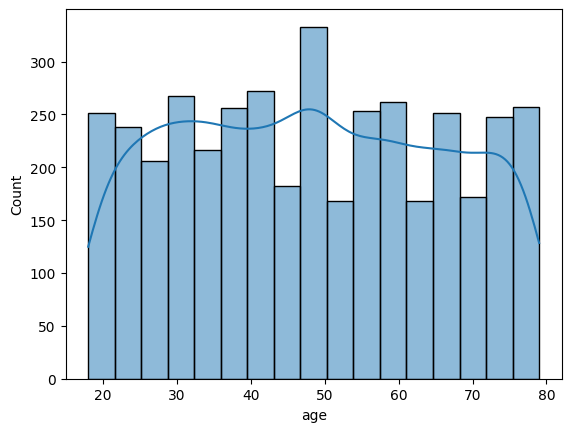

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', kde=True)
plt.show()

💡Insights:
- La edad de los usuarios de ConnectaTel muestra una amplia cobertura de mercado, abarcando desde adultos jóvenes (18 años) hasta adultos mayores (cerca de los 80 años).
- Se identifica una concentración notable de usuarios en el rango de los 48 a 50 años, representando el grupo etario más representativo de la base de datos analizada.

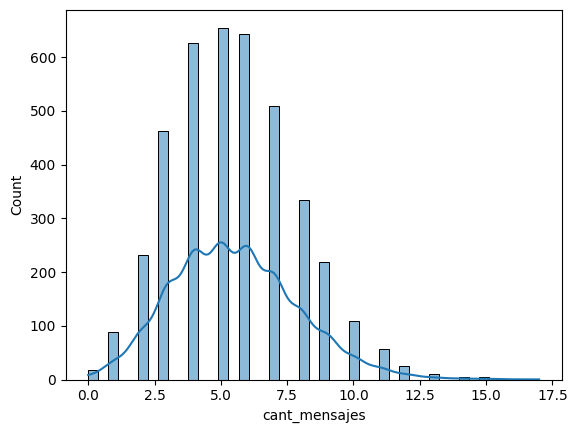

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', kde=True)
plt.show()


💡Insights:
- El análisis de distribución de mensajes revela que la gran mayoría de los clientes mantienen un volumen moderado de uso, agruparse densamente en el rango de 3 a 7 mensajes, con muy pocos usuarios superando el umbral de los 8 envíos.

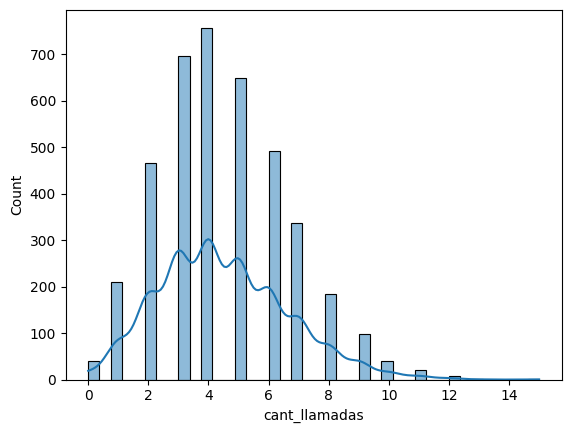

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', kde=True)
plt.show()

💡Insights:
- El comportamiento de las llamadas muestra un patrón acotado: la gran mayoría de la base de clientes realiza alrededor de 4 llamadas, con una cola hacia la derecha muy reducida que desciende fuertemente a partir de las 7 llamadas realizadas.

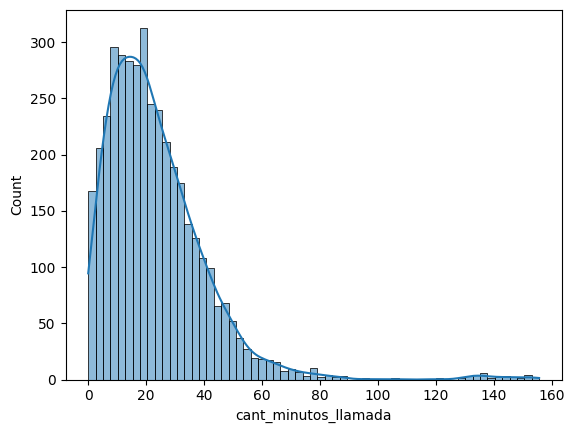

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', kde=True)
plt.show()

💡Insights:
- El análisis del tiempo en llamadas revela que la conducta predominante de los usuarios se orienta a duraciones breves; se observa un claro volumen pico de concentración en la franja de los 25-30 minutos, secundado por un repunte importante cerca de los 10 minutos, mientras que los consumos muy extensos representan una minoría con una marcada dispersión hacia la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

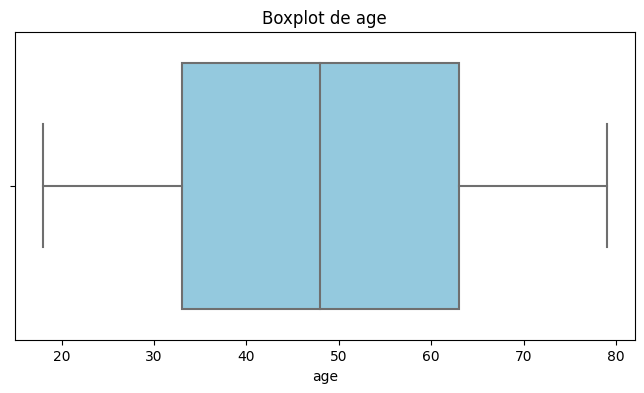

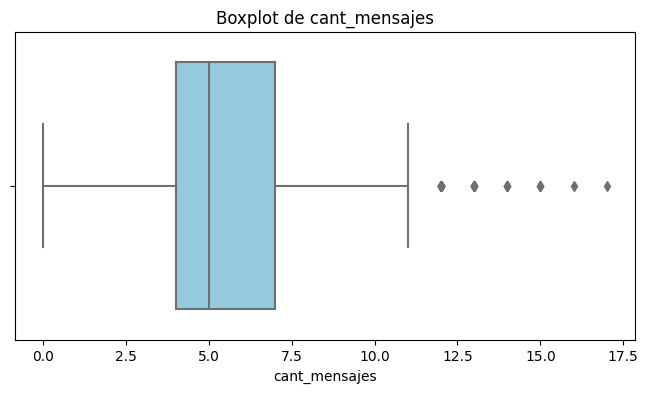

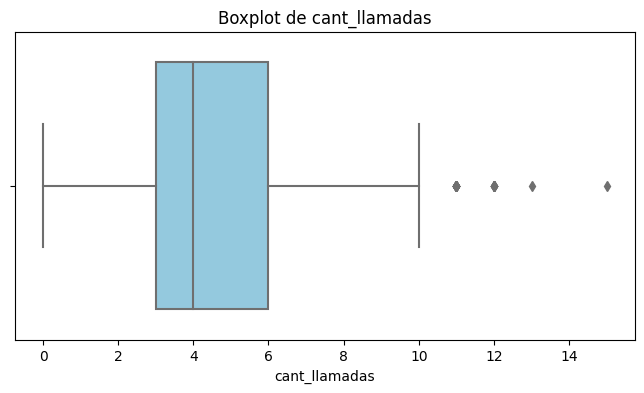

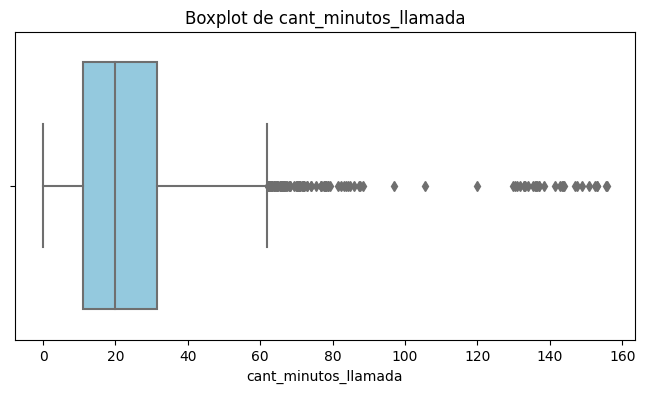

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.show()

💡Insights:
- Age: No presenta valores atípicos; la distribución se mantiene dentro del rango intercuartílico esperado.
- cant_mensajes: Presenta valores atípicos aislados en el extremo derecho (a partir de 12 mensajes), indicando usuarios con un nivel de envío superior al promedio.
- cant_llamadas: Muestra pequeños outliers a partir de las 11 llamadas, reflejando una cola positiva en la frecuencia de llamadas.
- cant_minutos_llamada: Presenta múltiples valores atípicos distribuidos en el rango de 95 a 155 minutos, correspondientes a clientes con consumos de tiempo elevados.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- **cant_mensajes: mantener o no outliers, porqué?**
    Al estar la media y la mediana casi idénticas, nos muestra una distribución central muy estable. Sin embargo, el salto del percentil 75 (7.0) al valor máximo (17.0) explica por qué el boxplot anterior mostraba pequeños puntos aislados a partir de los 12 mensajes. Se debe mantener porque representa a usuarios legítimos con mayor actividad (power users).
- **cant_llamadas: mantener o no outliers, porqué?**
    Al igual que los mensajes, la cercanía entre la media y la mediana ratifica que el comportamiento estándar de la base de clientes ronda las 4 llamadas. El valor máximo de 15 justifica los outliers detectados visualmente, los cuales reflejan un segmento real de clientes con mayor frecuencia de llamadas que no debe eliminarse para no sesgar la realidad del negocio.
- **cant_minutos_llamada: mantener o no outliers, porqué?**
    Aquí se evidencia una asimetría importante: la media es mayor que la mediana (reflejando el sesgo a la derecha) y el salto hacia el valor máximo (155.69) es drástico respecto al percentil 75. Esto comprueba numéricamente la existencia de la cola larga y los múltiples valores atípicos que vimos en los gráficos de caja. Se decide mantenerlos porque reflejan llamadas de duración muy extensa reales dentro del servicio de telecomunicaciones y no anomalías de captura de datos.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
import numpy as np
import pandas as pd

user_profile['cant_minutos_llamada'] = pd.to_numeric(user_profile['cant_minutos_llamada'], errors='coerce')

condiciones = [
    user_profile['cant_minutos_llamada'] <= 15,
    (user_profile['cant_minutos_llamada'] > 15) & (user_profile['cant_minutos_llamada'] <= 40),
    user_profile['cant_minutos_llamada'] > 40
]

segmentos = ['Bajo Uso', 'Uso Moderado', 'Alto Uso']

user_profile['grupo_uso'] = np.select(condiciones, segmentos, default='Sin Definir')

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Moderado
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso Moderado
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo Uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Bajo Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Moderado
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso Moderado
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo Uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Bajo Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
import numpy as np

condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

segmentos_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, segmentos_edad, default='Adulto Mayor')

user_profile[['user_id', 'age', 'grupo_edad']].head(10)

,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor
5,10005,61.0,Adulto Mayor
6,10006,39.0,Adulto
7,10007,70.0,Adulto Mayor
8,10008,76.0,Adulto Mayor
9,10009,47.0,Adulto


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Moderado,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso Moderado,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo Uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Bajo Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

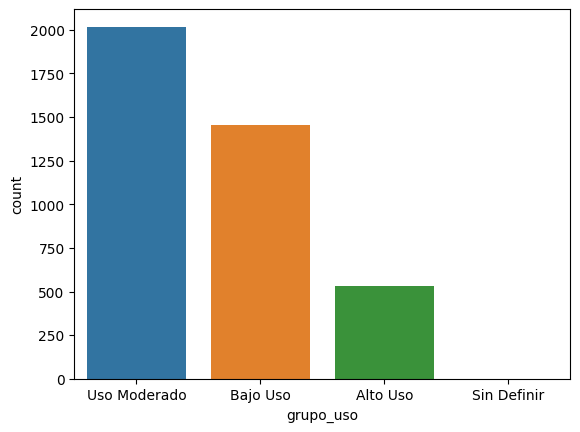

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.show()

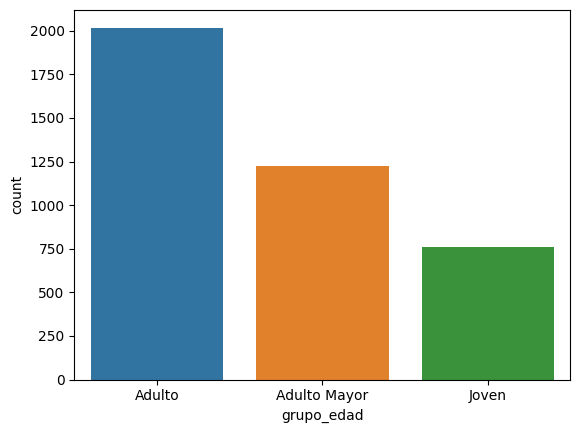

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

1. **Problemas originales de los datos y proporción**


   Diagnóstico inicial:

   Se detectó la presencia de valores nulos en las columnas duration y length del conjunto de datos de uso, afectando exactamente a 22,076 registros en cada columna.

    Comportamiento (MAR):

    Mediante el análisis condicional, se verificó que dichos valores faltantes responden a un patrón Missing At Random (MAR), condicionado por la naturaleza del evento. Los nulos en length ocurren exclusivamente en las llamadas, mientras que los nulos en duration se concentran en los mensajes de texto. Por lo tanto, la estructura de los datos es correcta y no requiere eliminación ni imputación.

3. **Segmentos de clientes identificados (Edad y Nivel de Uso)**


   Por Grupo de Edad (grupo_edad):

    La base de usuarios se clasificó en Jóvenes (menores de 30 años), Adultos (entre 30 y 59 años, con un núcleo concentrado alrededor de los 48 a 50 años) y Adultos Mayores (60 años en adelante), reflejando un mercado demográfico diversificado que se extiende hasta cerca de los 80 años.

    Por Nivel de Uso (grupo_uso):

   A través del análisis de los minutos de llamada, se establecieron las categorías de Bajo Uso, Uso Moderado y Alto Uso, identificando que el comportamiento general se concentra en duraciones moderadas, con un tiempo pico principal entre los 25 y 30 minutos.

5. **Segmentos de mayor valor estratégico para ConnectaTel**


   El segmento de Alto Uso y el núcleo demográfico de Adultos representan el mayor valor para la compañía.

    Justificación: El grupo de adultos conforma la base masiva y estable de suscriptores, mientras que los usuarios de alto consumo impulsan la rentabilidad operativa mediante una utilización intensiva y constante de la red de telecomunicaciones.

7. **Patrones de uso extremo (Outliers) y sus implicaciones**


    Hallazgos estadísticos:

   El análisis descriptivo y los diagramas de caja evidenciaron valores extremos en las métricas de consumo, con máximos de hasta 17 mensajes, 15 llamadas y picos de 155.69 minutos en llamadas.

    Implicación de negocio:

   Se determinó mantener estos registros, ya que no corresponden a errores técnicos de captura, sino a un segmento legítimo de usuarios de alto rendimiento ("power users"). Su conservación resulta indispensable para modelar la realidad de la demanda y el consumo intensivo.

9. **Recomendaciones comerciales y estratégicas**


   Diseño de planes especializados:

   Desarrollar ofertas comerciales de nivel Premium dirigidas a los usuarios de Alto Uso, permitiendo monetizar de forma adecuada los volúmenes elevados de minutos y mensajes.

    Estrategias de retención:

   Implementar campañas de fidelización enfocadas en el segmento demográfico dominante (adultos maduros), con el fin de asegurar la estabilidad de la cartera.

Campañas de reactivación: Utilizar la segmentación de Bajo Uso para diseñar promociones e incentivos que impulsen una mayor interacción dentro de la plataforma.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de valores nulos en las columnas duration y length (22,076 registros afectados en cada una), los cuales siguen un patrón Missing At Random (MAR) condicionado por el tipo de evento.
- Validación de la estructura de datos, determinando que los nulos responden a la naturaleza propia de los servicios (llamadas o mensajes) y no requieren eliminación ni imputación.


🔍 **Segmentos por Edad**
- Clasificación de la base de usuarios en Jóvenes, Adultos (núcleo principal concentrado alrededor de los 48 a 50 años) y Adultos Mayores.
- Demografía amplia y diversificada que abarca desde adultos jóvenes hasta usuarios cercanos a los 80 años.


📊 **Segmentos por Nivel de Uso**
- Agrupación de los clientes en Bajo Uso, Uso Moderado y Alto Uso con base en los volúmenes y minutos de consumo.
- Comportamiento general concentrado en duraciones moderadas, con un tiempo pico principal entre los 25 y 30 minutos, acompañado de una cola de consumo intensivo.


➡️ Esto sugiere que ...
- Los datos reflejan un comportamiento orgánico de la demanda; los valores extremos detectados corresponden a clientes legítimos de alto rendimiento ("power users") y no a anomalías técnicas, lo que valida su conservación para los modelos de negocio.

💡 **Recomendaciones**
- Desarrollar ofertas comerciales de nivel Premium dirigidas al segmento de Alto Uso para monetizar adecuadamente el consumo elevado de minutos y mensajes.
- Implementar estrategias de retención y campañas de reactivación diferenciadas según el perfil demográfico y el nivel de uso de la cartera de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`